In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway, kruskal

# Load cleaned data
countries = ['ethiopia', 'kenya', 'nigeria', 'sudan', 'tanzania']
all_data = []

for c in countries:
    df = pd.read_csv(f'../data/{c}_clean.csv')
    df['Country'] = c.capitalize() # Ensure country names are capitalized for the legend
    all_data.append(df)

# Combine into one master dataframe
df_master = pd.concat(all_data, ignore_index=True)

# Convert Date to datetime for plotting
df_master['Date'] = pd.to_datetime(df_master['Date'])

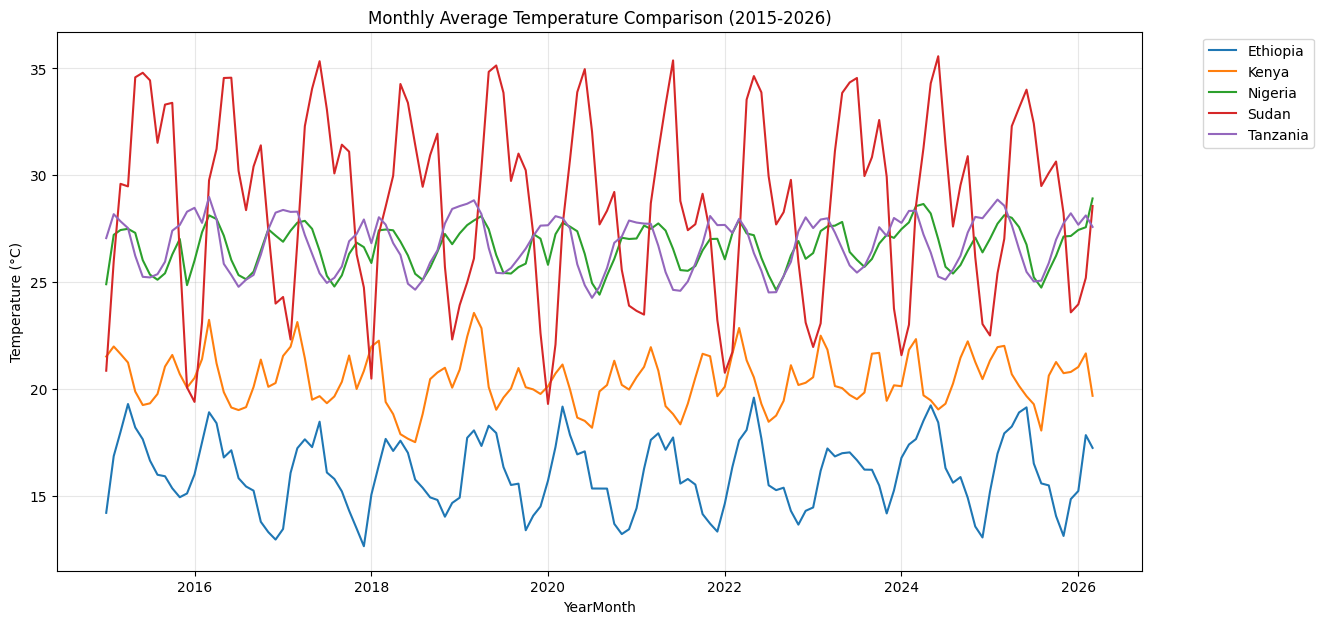

Temperature Summary Statistics:


,mean,median,std_dev
Country,,,
Ethiopia,16.068500,16.04,1.898050
Kenya,20.427600,20.36,1.440824
Nigeria,26.656928,26.82,1.123335
Sudan,28.759007,29.16,4.681305
Tanzania,26.802422,26.99,1.325388


In [2]:
# Group by Month and Country for the line chart
df_master['YearMonth'] = df_master['Date'].dt.to_period('M')
monthly_temp = df_master.groupby(['YearMonth', 'Country'])['T2M'].mean().reset_index()
monthly_temp['YearMonth'] = monthly_temp['YearMonth'].dt.to_timestamp()

plt.figure(figsize=(14, 7))
sns.lineplot(data=monthly_temp, x='YearMonth', y='T2M', hue='Country')
plt.title('Monthly Average Temperature Comparison (2015-2026)')
plt.ylabel('Temperature (°C)')
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Summary Table for Temp
temp_summary = df_master.groupby('Country')['T2M'].agg(['mean', 'median', 'std']).rename(columns={'std': 'std_dev'})
print("Temperature Summary Statistics:")
display(temp_summary)

C:\Users\mekli\AppData\Local\Temp\ipykernel_13480\2776225843.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_master, x='Country', y='PRECTOTCORR', palette='viridis')


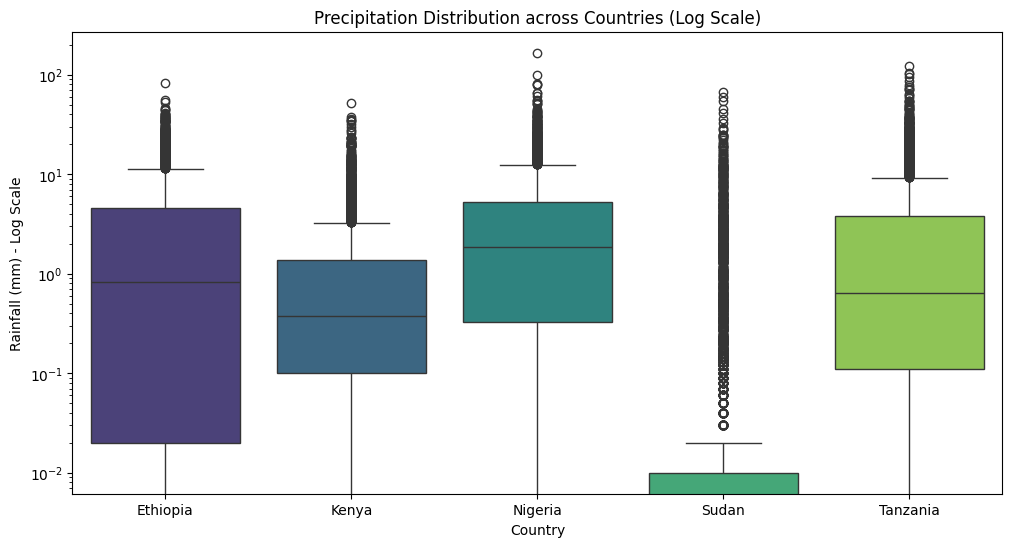

Precipitation Summary Statistics:


,mean,median,std_dev
Country,,,
Ethiopia,3.633795,0.82,6.289061
Kenya,1.468162,0.38,3.180228
Nigeria,4.213914,1.84,7.266742
Sudan,0.643875,0.00,3.057672
Tanzania,3.740256,0.64,8.003947


In [4]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_master, x='Country', y='PRECTOTCORR', palette='viridis')
plt.yscale('log') # Log scale helps see the distribution since rain has many 0s
plt.title('Precipitation Distribution across Countries (Log Scale)')
plt.ylabel('Rainfall (mm) - Log Scale')
plt.show()

# Summary Table for Rain
rain_summary = df_master.groupby('Country')['PRECTOTCORR'].agg(['mean', 'median', 'std']).rename(columns={'std': 'std_dev'})
print("Precipitation Summary Statistics:")
display(rain_summary)

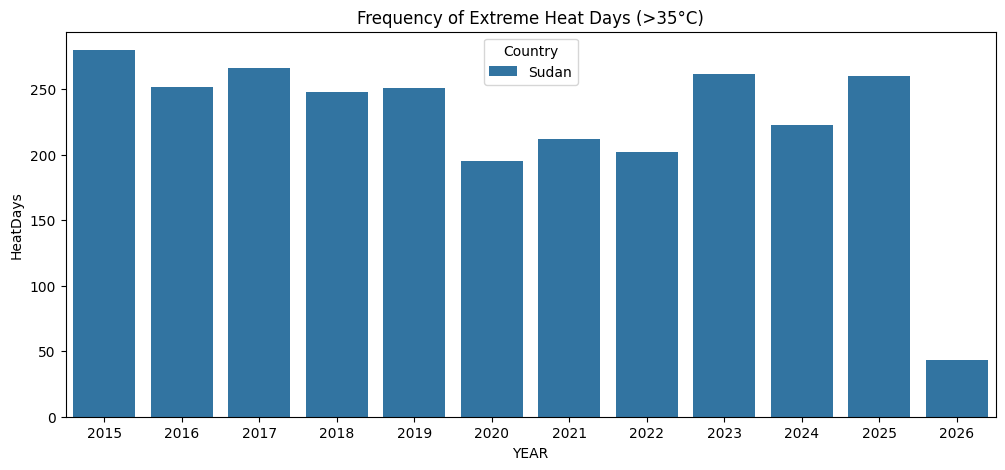

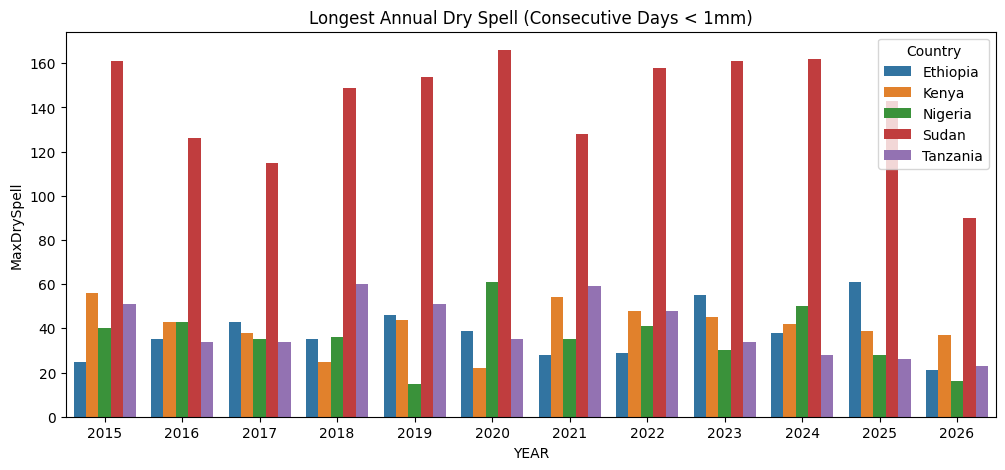

In [5]:
# 1. Extreme Heat (> 35°C)
extreme_heat = df_master[df_master['T2M_MAX'] > 35].groupby(['Country', 'YEAR']).size().reset_index(name='HeatDays')

# 2. Consecutive Dry Days (Complex Calculation)
def max_dry_spell(series):
    is_dry = series < 1
    # This logic identifies groups of consecutive dry days
    return is_dry.groupby((~is_dry).cumsum()).sum().max()

drought_stats = df_master.groupby(['Country', 'YEAR'])['PRECTOTCORR'].apply(max_dry_spell).reset_index(name='MaxDrySpell')

# Visualizing Heat Days
plt.figure(figsize=(12, 5))
sns.barplot(data=extreme_heat, x='YEAR', y='HeatDays', hue='Country')
plt.title('Frequency of Extreme Heat Days (>35°C)')
plt.show()

# Visualizing Drought
plt.figure(figsize=(12, 5))
sns.barplot(data=drought_stats, x='YEAR', y='MaxDrySpell', hue='Country')
plt.title('Longest Annual Dry Spell (Consecutive Days < 1mm)')
plt.show()

In [6]:
# One-way ANOVA
groups = [df_master[df_master['Country'] == c]['T2M'] for c in df_master['Country'].unique()]
f_stat, p_val = f_oneway(*groups)

print(f"ANOVA Results: F-Statistic = {f_stat:.2f}, p-value = {p_val:.4e}")
if p_val < 0.05:
    print("Conclusion: The differences in mean temperatures across these countries are statistically significant.")

ANOVA Results: F-Statistic = 18938.75, p-value = 0.0000e+00
Conclusion: The differences in mean temperatures across these countries are statistically significant.


## 6. Climate Vulnerability Ranking

Based on the statistical evidence synthesized from 2015–2026, the five countries are ranked by their cumulative exposure to extreme climate stress (Heat, Rainfall Volatility, and Drought Frequency):

| Rank | Country | Primary Vulnerability | Data Justification (Baseline: 2015–2026) |
| :--- | :--- | :--- | :--- |
| **1** | **Sudan** | Extreme Heat & Aridity | Highest mean temp (**28.76°C**) and extreme annual dry spells exceeding 160 days. |
| **2** | **Nigeria** | Flood Risk | Highest mean precipitation (**4.21mm**) and high variability indicating intense storm events. |
| **3** | **Tanzania** | Precipitation Instability | Highest rainfall standard deviation (**8.00**), suggesting highly unpredictable seasons. |
| **4** | **Kenya** | Moderate Drought | Low mean rainfall (**1.46mm**) with significant annual dry-day counts. |
| **5** | **Ethiopia** | Thermal Stability | Lowest mean temperature (**16.07°C**) and the most consistent seasonal cycles. |

---

## 7. COP32 Position Paper: Key Observations

These findings serve as the empirical foundation for Ethiopia's leadership at the upcoming COP32 summit in Addis Ababa:

* **Sudan is the most thermally stressed:** With a mean temperature of **28.76°C** and consistent daily maximums exceeding **35°C**, Sudan faces an immediate desertification crisis that threatens regional food security.
* **Tanzania exhibits the most unstable precipitation:** A standard deviation of **8.00** in rainfall—the highest in the study group—indicates extreme swings between dry and wet periods, demanding robust flood-control infrastructure.
* **The "Double Threat" of Heat and Drought:** Sudan faces over 200 extreme heat days annually alongside dry spells lasting nearly half a year, creating a state of permanent climate stress and reduced labor productivity.
* **Ethiopia as a Regional Baseline:** Ethiopia maintains a unique, cooler profile (**mean 16.07°C**) compared to its neighbors. While more thermally stable, it remains vulnerable to the regional shifts in rainfall stability observed in the Horn of Africa.
* **Priority for Climate Finance:** **Sudan** should be championed for priority adaptation finance. The data proves it is the regional "hotspot" for extreme heat and prolonged drought, requiring urgent global investment in water security and heat-resilient agriculture.